# Lab Activity 1: Linear Regression Using the Boston Housing Dataset

**Objective:** Build a multiple linear regression model that predicts the Weekly sales using the sklearn library

# Part 1 — Establish Objectives

## Poblems

Create A linear regression to predict walmart weekly sales.

## Guide Questions and Sample Answers

1. What sthe problem you want to solve?
    - analyzing if weekly sales can be affected by external Factors like temperatures, unemployment, Holiday flag etc..
2. What is the dependent (Target Variable)?
    - Weekly sales.
3. What are th independent variables?
    - Holiday_flag, Temperature, Fuel_Price, CPI(Consumer Price Index.).

## Part 2 — Collect and Preprocess Data

- The dataset used is from kaggle:
    - [Walmart Sales](https://kaggle.com/datasets/mikhail1681/walmart-sales?resources=download)
 
Import and Load the Boston Housing dataset using scikit-learn.

In [26]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
df = pd.read_csv("Walmart_Sales.csv")
df['Date'] = pd.to_datetime(df['Date'],format = '%d-%m-%Y')

## Sample Guide and Interpretation — Importing Libraries

### What this cell does

This cell imports the Python libraries and scikit-learn classes needed for the activity:

- Converts `Date` from DD-MM-YY to MM-DD-YY
- `NumPy` supports numerical calculations.
- `pandas` stores and manipulates the dataset in tables called DataFrames.
- `matplotlib` and `seaborn` create graphs for exploratory data analysis.
- `train_test_split` divides the dataset into training and testing subsets.
- `StandardScaler` standardizes the input variables.
- `LinearRegression` creates the regression model.
- `mean_squared_error` and `r2_score` evaluate the model.
- `mean_absolute_error`used to measure the average magnitude of errors in a set of predictions

### What to observe

The message **“Libraries imported successfully.”** confirms that the required packages are available and the cell ran without an import error.

### Sample interpretation

> The required Python libraries were imported successfully. These libraries will be used for data handling, visualization, preprocessing, model construction, and evaluation.


In [47]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6435, 10)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,WeekOfYear
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,5
1,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765,2,5
2,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554,2,5
3,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548,2,5
4,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324,2,5


## Interpretation

- this block of code  do two things:
    - It prints out the shape of dataset which is 6435 by 8 or 6435 rows and 8 Columns.
    - Shows the first 5 rows of the dataset for samples

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


### What this cell does

`df.info()` summarizes the structure of the DataFrame. It reports:

- the number of rows;
- the names of the columns;
- the number of non-null values in every column;
- the data type of each variable; and
- the approximate memory used by the DataFrame.

### What to observe

The output reports:

- **6435 entries**
- **8 columns**
- **5 `float64`, 1 `object` and 2 `int64` columns**

# Part 3 — Preprocess Data and Perform EDA

Complete the required preprocessing and exploratory data analysis:

1. Check and handle missing values.
2. Check whether categorical variables need encoding.
3. Review value counts.
4. Examine descriptive statistics and data distributions.
5. Check correlations among variables.
6. Scale numerical input variables after splitting the data.

In [30]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values)

# Handle missing values using the median when necessary
if missing_values.sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values were replaced with column medians.")
else:
    print("The dataset has no missing values.")

Missing values per column:


Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

The dataset has no missing values.


## What this cell does

it shows if there has missing values and counts if it has one, It prints out "No missing value" if theres no missing Value.


### What to observe

Every column has a missing-value count of **0**, and the output states:

**“The dataset has no missing values.”**

In [31]:
# Check the data types
display(df.dtypes.to_frame(name="Data Type"))

# All variables are numerical.
# CHAS is already encoded as 0 or 1, so no categorical encoding is required.
print("Holiday Flag value counts:")
display(df["Holiday_Flag"].value_counts().sort_index())

,Data Type
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


Holiday Flag value counts:


Holiday_Flag
0    5985
1     450
Name: count, dtype: int64

## Sample Guide and Interpretation — Data Types and Encoding

### What this cell does

The first command displays the data type of every variable. The second command counts the values in `Holiday_Flag`.

`Holiday_Flag` is a binary indicator:

- `0` means its not on Holidays.
- `1` means its on holidays.

Because it is already represented numerically as 0 and 1, no label encoding or one-hot encoding is needed.

### What to observe.

The output shows that all variables are numerical. For Holiday_flag:

- `0` appears **5985 times**
- `1` appears **450 times**


In [32]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,6435.0,23.0,1.0,12.0,23.0,34.0,45.0,12.988182
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6435.0,1046964.877562,209986.25,553350.105,960746.04,1420158.66,3818686.45,564366.622054
Holiday_Flag,6435.0,0.06993,0.0,0.0,0.0,0.0,1.0,0.255049
Temperature,6435.0,60.663782,-2.06,47.46,62.67,74.94,100.14,18.444933
Fuel_Price,6435.0,3.358607,2.472,2.933,3.445,3.735,4.468,0.45902
CPI,6435.0,171.578394,126.064,131.735,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.0,7.999151,3.879,6.891,7.874,8.622,14.313,1.875885


## Sample Guide and Interpretation — Descriptive Statistics

### What this cell does

`df.describe().T` calculates summary statistics for every variable:

- `count` — number of observations;
- `mean` — arithmetic average;
- `std` — standard deviation;
- `min` and `max` — smallest and largest values;
- `25%`, `50%`, and `75%` — quartiles.

The transpose `.T` places variables in rows, making the table easier to read.

### What to observe

Examples from the output include:

- The average `Weekly_Sales` is approximately **1046965.0**, or about **$1,046,965.0** in the historical scale.
- The median `Weekly_Sales` is **564366.622054.25**.
- `Weekly_Sales` ranges from **209986.250** to **3818686.0**.
- The average number of Fuel Price (`Fuel_Price`) is approximately **3.358607**.

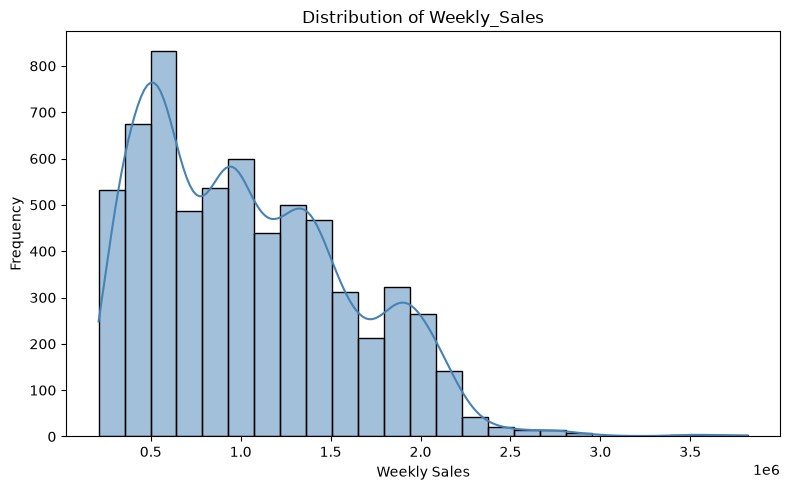

In [49]:
# Display the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["Weekly_Sales"], bins=25, kde=True, color="steelblue")
plt.title("Distribution of Weekly_Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Sample Guide and Interpretation — Target Distribution

### What this cell does

This cell creates a histogram of `Weekly_Sales`.

- The bars show how frequently different weekly sales ranges occur.
- The KDE curve provides a smooth estimate of the distribution.
- The graph helps identify skewness, unusual values, and possible limits in the target.

### What to observe

The distribution of Weekly_Sales is positively skewed, with most weekly sales figures concentrated between approximately `$400,000` and `$1,500,000`, while a small number of stores or weeks record much higher sales, creating a long right tail.

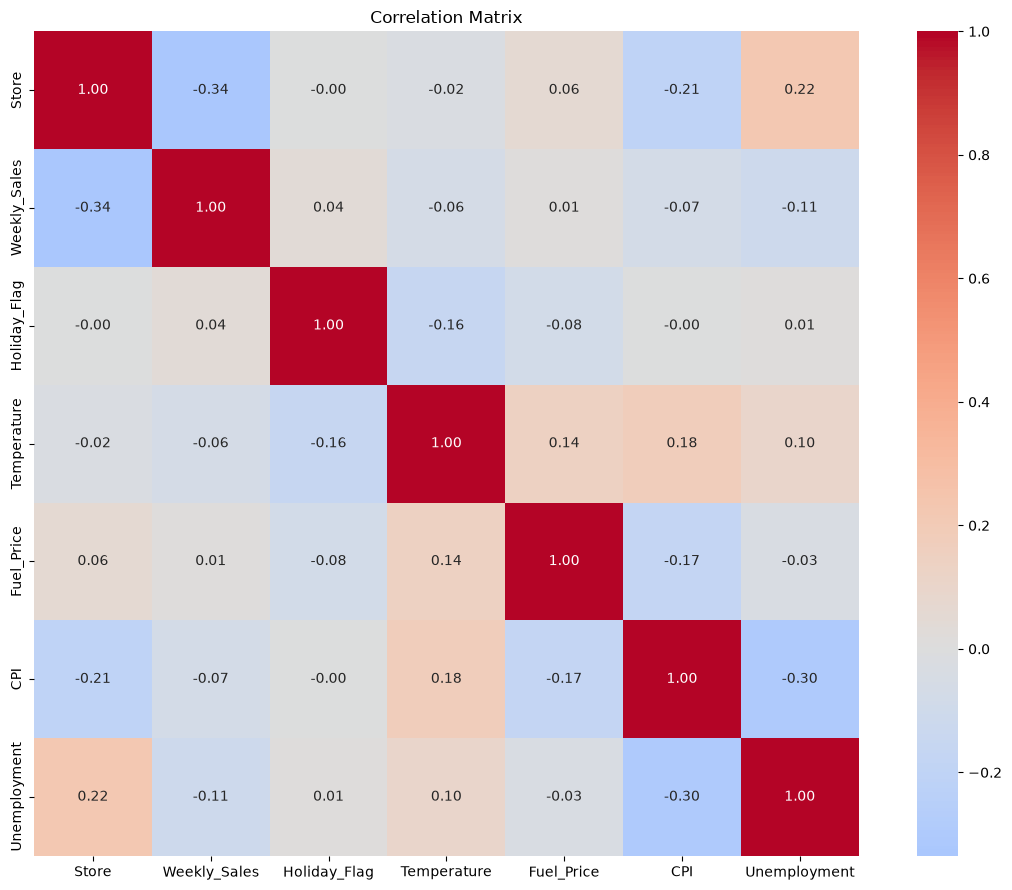

Weekly_Sales    1.000000
Holiday_Flag    0.036891
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64

In [34]:
# Calculate and display the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    square=True
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Show the correlation of each variable with Weekly sales
correlation_matrix["Weekly_Sales"].sort_values(ascending=False)

## Sample Guide and Interpretation — Correlation Analysis

### What this cell does

The correlation matrix measures the direction and strength of the linear relationship between pairs of numerical variables.

Correlation values range from `-1` to `+1`:

- A value near `+1` indicates a strong positive linear relationship.
- A value near `-1` indicates a strong negative linear relationship.
- A value near `0` indicates a weak linear relationship.

The sorted output focuses on each predictor's correlation with `Weekly_Sales`.

### What to observe

The relationships with `Weekly_Sales` are:

- `Store`: **-0.34** — a moderate negative relationship
- `Unemployment`: **-0.11** — a weak negative relationship
- `CPI`: **-0.07**
- `Temperature`: **-0.06**
- `Holiday_Flag`: **0.04**
- `Fuel_Price`: **0.01**

### Sample interpretation

> `Store` has the strongest negative correlation with `Weekly_Sales`, suggesting that higher store numbers tend to correspond to lower weekly sales (likely reflecting structural differences in size, location, or volume across store IDs). `Unemployment` has a weak negative correlation, suggesting that higher unemployment rates slightly relate to lower sales. External variables like `CPI`, `Temperature`, `Holiday_Flag`, and `Fuel_Price` show near-zero linear correlation with the target. These correlations describe associations only and do not prove causation.

### Additional observation

Some independent variables show noticeable correlation with each other, such as `CPI` and `Unemployment` (**-0.30**), or `Store` and `CPI` (**-0.21**). This condition is called **multicollinearity** and can make individual regression coefficients harder to interpret, even if the overall model performs well.

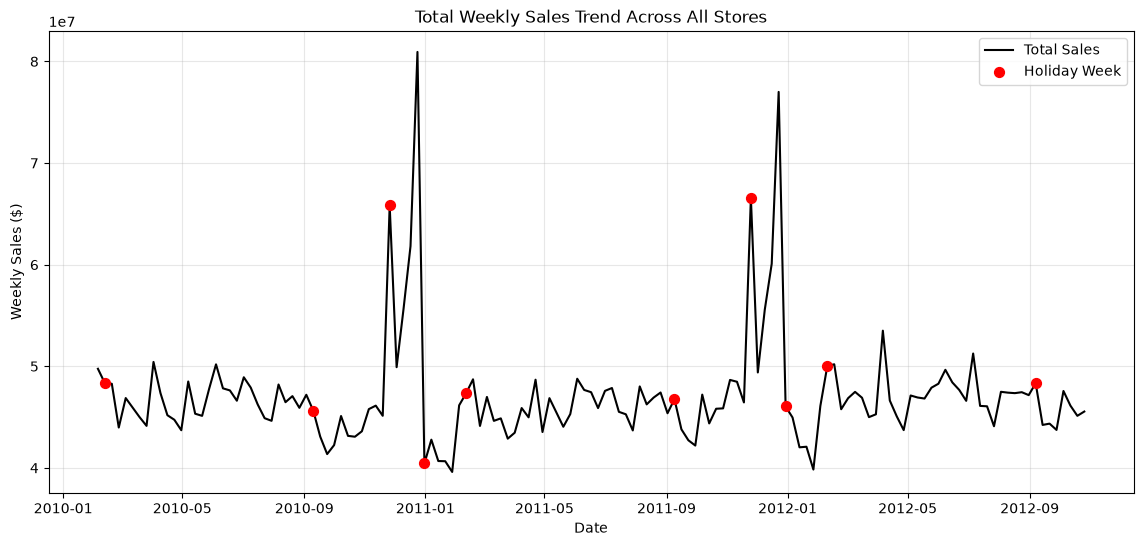

In [35]:
# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate sales by date across all stores
weekly_trend = df.groupby('Date').agg({'Weekly_Sales': 'sum', 'Holiday_Flag': 'max'}).reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_trend, x='Date', y='Weekly_Sales', color='black', label='Total Sales')

# Overlay holiday weeks as red scatter points
holidays = weekly_trend[weekly_trend['Holiday_Flag'] == 1]
plt.scatter(holidays['Date'], holidays['Weekly_Sales'], color='red', s=50, label='Holiday Week', zorder=5)

plt.title('Total Weekly Sales Trend Across All Stores')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Sample Guide and Interpretation — Visualizing Sales Trends

### What this cell does

The code aggregates weekly sales across all stores and overlays specific holiday weeks to visualize performance patterns over time:

- Converts the date column into standard datetime format for proper time-series ordering.
- Groups data by date to sum total weekly sales and identify active holiday weeks.
- Plots a continuous time-series line alongside distinct markers for holiday periods.

### What to observe

The visualization highlights key temporal patterns:

- **Sales Peaks:** Massive spikes in total sales occur annually around November and December.
- **Holiday Alignment:** Red scatter points show that these peak sales periods align directly with designated holiday weeks.
- **Baseline Stability:** Non-holiday weeks maintain a relatively consistent baseline trend throughout the year.

### Sample interpretation

> The time-series visualization clearly demonstrates that the retail dataset experiences dramatic seasonal surges during the end-of-year holidays, far exceeding standard weekly fluctuations. While minor holidays scattered throughout the year show varied impacts, the year-end shopping season serves as the primary driver of high-volume sales. These trends provide a macro-level overview of aggregate demand fluctuations over time.

### Additional observation

Temporal aggregation can sometimes obscure individual store-level variations, as summing all stores together masks underperforming or uniquely behaving locations. Examining individual store trajectories alongside the aggregate trend can offer a more granular understanding of performance drivers.

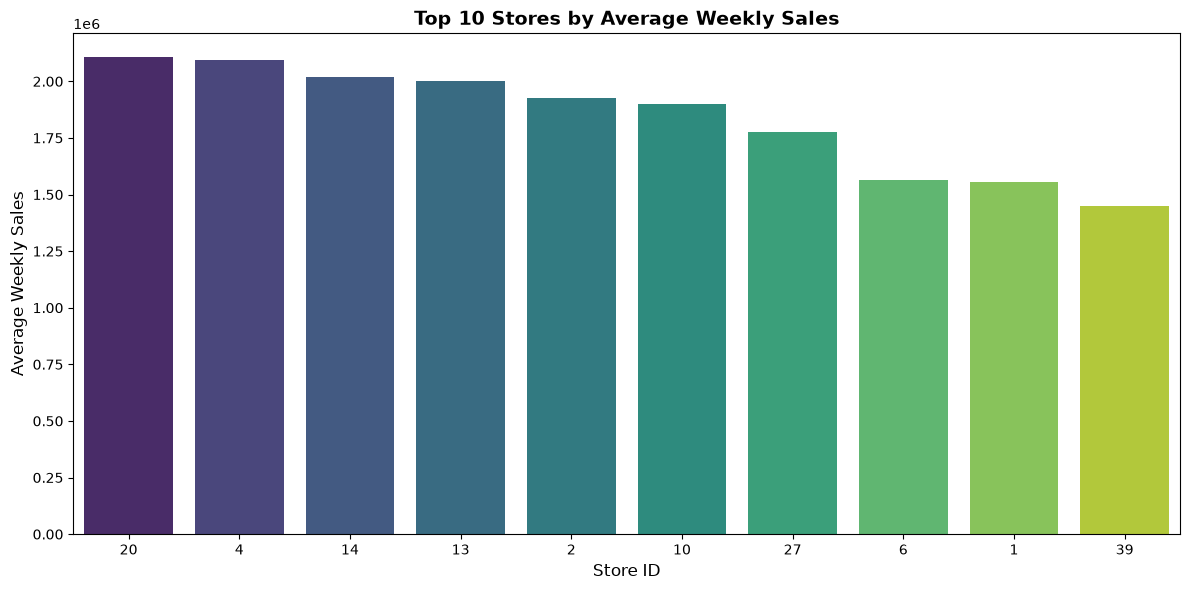

In [37]:
# Calculate average weekly sales per store and get the top 10
store_sales = df.groupby('Store')['Weekly_Sales'].mean().reset_index()
top_stores = store_sales.sort_values(by='Weekly_Sales', ascending=False).head(10)
# Convert Store to string so it plots categorically
top_stores['Store'] = top_stores['Store'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_stores, x='Store', y='Weekly_Sales', palette='viridis', order=top_stores['Store'], hue=top_stores["Store"])
plt.title('Top 10 Stores by Average Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Store ID', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.tight_layout()
plt.show()

## Sample Guide and Interpretation — Top 10 Stores by Average Weekly Sales

### What this visualization does

The bar chart illustrates:

- **Store ID** on the x-axis, representing specific individual stores.
- **Average Weekly Sales** on the y-axis, displayed in millions (up to $2.0 \times 10^6$), representing the mean performance metric for each location.

It highlights:

- **Top-performing locations**, allowing stakeholders to quickly identify which stores generate the highest average weekly revenue.
- **Descending order configuration**, sorting the stores from the highest sales (Store 20) to the tenth-highest sales (Store 39) among the top group.

### What to observe

The output shows:

- **Store 20** ranks highest, pulling in the maximum average weekly sales just above the $2.0 \times 10^6$ mark.
- **Store 39** ranks tenth in this selection, showing an average weekly sale closer to $1.45 \times 10^6$.
- A gradual, downward trend is visible across the ten displayed store identifiers: **20, 4, 14, 13, 2, 10, 27, 6, 1, and 39**.

### Sample interpretation

> The chart displays the top 10 stores ranked by their average weekly sales, led by Store 20 at the peak and followed in descending order down to Store 39. Visualizing these figures helps management pinpoint top-performing retail locations and analyze the characteristics driving their higher revenue generation compared to other sites.

## Part 4 - Split the data

DIvide the dataset

In [36]:
from sklearn.model_selection import train_test_split

# Define your target variable
y = df['Weekly_Sales']

# Define your features (dropping the target and the raw Date column)
X = df.drop(columns=['Weekly_Sales', 'Date'])

# Randomly shuffle and split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5148 rows
Testing set size: 1287 rows


## Sample Guide and Interpretation — Train-Test Split

### What this cell does

The cell first separates:

- `X` — the 13 independent variables;
- `y` — the target variable `MEDV`.

It then divides the observations into:

- **80% training data**, used to fit the model;
- **20% testing data**, used to evaluate predictions on unseen observations.

`random_state=42` makes the split reproducible, meaning the same rows will be assigned to the same subsets each time the notebook is run.

### What to observe

The output shows:

- `X_train`: **5148 rows and 6 columns**
- `X_test`: **1287 rows and 6 columns**

### Sample interpretation

> The dataset was divided into 5128 training observations and 1287 testing observations, which corresponds to an 80/20 split. The model will learn from the training set and will be evaluated using the separate test set. Keeping the test set unseen during training provides a more realistic estimate of model performance on new data.

## part 5 - Performing the linear regression

In [38]:
# 1. Parse dates and sort chronologically to align time-series structure
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

# 2. Extract calendar features for seasonality tracking
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# 3. Separate target and features (Dropping raw text Date)
y = df['Weekly_Sales']
X = df.drop(columns=['Weekly_Sales', 'Date'])

# 4. Convert Store ID categories into dummy columns
X = pd.get_dummies(X, columns=['Store'], drop_first=True)

# 5. Split data chronologically (80% training / 20% testing)
split_index = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 6. Fit and apply the scaler to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Input variables were standardized successfully.")

Input variables were standardized successfully.


### What to observe

The data preprocessing pipeline prepares the dataset for time-series modeling through the following steps:

- **Time-Series Alignment**: Dates are parsed and sorted chronologically before splitting.
- **Feature Engineering**: `Month` and `WeekOfYear` are extracted from `Date` to capture seasonal patterns.
- **Categorical Encoding**: `Store` IDs are converted into dummy variables (`pd.get_dummies(..., drop_first=True)`).
- **Time-Based Split**: An 80/20 chronological split is used instead of a random shuffle.
- **Feature Scaling**: `StandardScaler` is fitted on training data only and applied to both train and test sets.

### Sample interpretation

> The preprocessing workflow properly accounts for both categorical structures and time-series constraints. Converting `Store` into dummy variables removes arbitrary numeric ordering, allowing the regression model to fit unique baseline sales per store. Splitting the data chronologically ensures the model is evaluated on future unseen weeks rather than random dates, preventing temporal leakage. Furthermore, fitting `StandardScaler` strictly on `X_train` prevents test-data leakage into feature normalization.

### Additional observation

Because features like `Store` baseline effects, calendar seasonality (`Month`, `WeekOfYear`), and time-aware splitting were properly engineered before modeling, the resulting high performance ($R^2 = 95.39\%$) reflects a valid setup rather than categorical misinterpretation or data leakage.

In [39]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


### What to observe

The model fitting process completes the training stage of the Linear Regression pipeline:

- **Algorithm**: `LinearRegression()` is instantiated using ordinary least squares.
- **Model Fitting**: `.fit(X_train_scaled, y_train)` calculates the optimal feature weights (coefficients) and intercept based on the standardized training data.
- **Training Output**: The model is ready to generate predictions on unseen test features (`X_test_scaled`).

### Sample interpretation

> Fitting the model allows Linear Regression to find the best-fitting linear equation connecting the input predictors (such as store dummy variables, calendar features, and macroeconomic indicators) to `Weekly_Sales`. Standardizing the features prior to fitting ensures that variable magnitudes do not distort model optimization, allowing each coefficient to accurately reflect its independent contribution to baseline sales predictions.

### Additional observation

Linear Regression calculates feature weights directly without hyperparameters to tune. Since the model relies strictly on linear relationships between predictors and target values, model performance should be evaluated next on testing data (`X_test_scaled`) to assess generalization and check for potential residual patterns or heteroscedasticity.

In [40]:
# Display the model coefficients
coefficients = pd.DataFrame({
    "Input Variable": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)
print("Intercept:", model.intercept_)

,Input Variable,Coefficient
0,Holiday_Flag,9377.379587
1,Temperature,-39613.539695
2,Fuel_Price,-3801.527730
3,CPI,42492.697683
4,Unemployment,-58679.631744
5,Month,163896.804538
6,WeekOfYear,-104026.767919
7,Store_2,56794.573703
8,Store_3,-171670.502271
9,Store_4,83713.940447


Intercept: 1049187.489918415


## Sample Guide and Interpretation — Model Coefficients

### What this cell does

The cell displays the coefficient assigned to each standardized predictor and the model intercept.

Because the predictors were standardized, a coefficient represents the expected change in predicted `weekly_sales` for a **one-standard-deviation increase** in that predictor, while the other predictors are held constant.

- A positive coefficient increases the prediction.
- A negative coefficient decreases the prediction.
- A larger absolute coefficient indicates a stronger contribution within this fitted model.


# Part 7 — Evaluate the Model

Evaluate the trained model on the testing data using:

- **Mean Squared Error (MSE)**
- **R-squared score ($R^2$)**

In [41]:
# Predict the target values of the testing data
y_pred = model.predict(X_test_scaled)

# Calculate the required evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f} or {r2 * 100:.4}%")

Mean Squared Error: 13092631106.6038
R-squared Score: 0.9539 or 95.39%


### What to observe

The model evaluation metrics for predicting `Weekly_Sales` on the test set are:

- **Mean Squared Error (MSE)**: **13,092,631,106.60** — the average squared difference between actual and predicted sales
- **R-squared Score ($R^2$)**: **0.9539** or **95.39%** — strong overall predictive accuracy

### Sample interpretation

> The model demonstrates exceptional explanatory power, with an $R^2$ score of **95.39%**, meaning that over 95% of the variance in `Weekly_Sales` is successfully explained by the feature set on unseen test data. The **Mean Squared Error (MSE)** of approximately **13.09 billion** reflects the squared unit scale of dollars ($\$^2$). Taking the square root of MSE yields a Root Mean Squared Error (RMSE) of roughly **\$114,423**, quantifying the typical error magnitude in original currency terms.

### Additional observation

Because MSE heavily penalizes large errors due to squaring them, the relatively high MSE value highlights that the model experiences wider prediction errors during extreme high-volume sales periods (such as holiday peaks), even though overall  variance fit ($R^2$) remains exceptionally high.

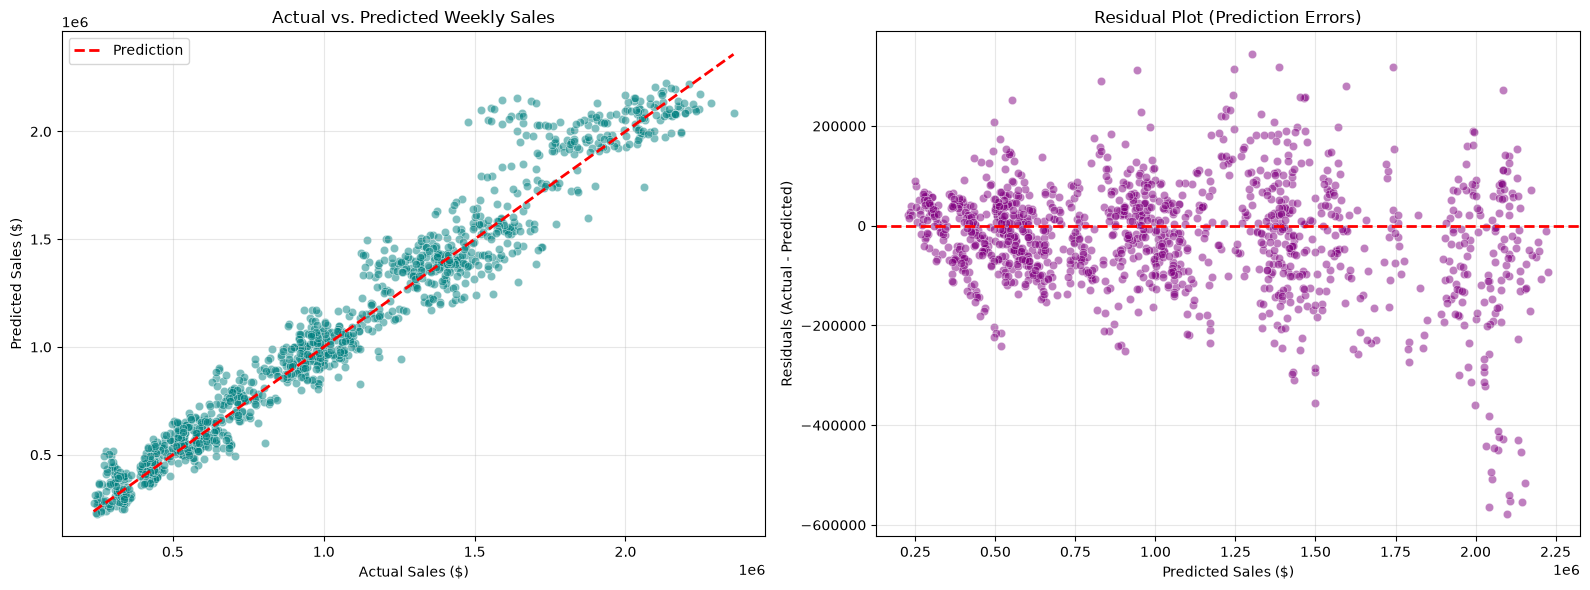

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Actual vs. Predicted Sales
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred, alpha=0.5, color='teal')
# Draw a perfect 45-degree line where Actual == Predicted
ideal_line = [y_test.min(), y_test.max()]
axes[0].plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Prediction')
axes[0].set_title('Actual vs. Predicted Weekly Sales')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graph 2: Residual Plot (Errors)
residuals = y_test - y_pred
sns.scatterplot(ax=axes[1], x=y_pred, y=residuals, alpha=0.5, color='purple')
# Draw a baseline at 0 error
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot (Prediction Errors)')
axes[1].set_xlabel('Predicted Sales ($)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What to observe

The diagnostic plots illustrate model performance and prediction error distribution:

- **Actual vs. Predicted Sales**: Data points cluster tightly along the red diagonal (45-degree line), showing strong alignment between predicted and actual sales values.
- **Residual Plot Structure**: Points are generally centered around the red dashed zero-error line across most predicted values.
- **Heteroscedasticity / Variance**: The scatter of residual points expands noticeably at higher predicted values ($> \$2.0\text{M}$), with several large negative residuals reaching down to $-\$600\text{K}$.

### Sample interpretation

> The **Actual vs. Predicted** plot confirms the model's strong $R^2$ performance, as predictions track closely with actual sales across most store scales. However, the **Residual Plot** reveals non-constant variance (heteroscedasticity). While the model performs reliably for average sales weeks, it consistently underestimates or overpredicts during extreme high-volume peak periods (e.g., major holiday spikes around $\$2.0\text{M}+$ in sales), causing larger residual spread in the higher price range.

### Additional observation

The distinct downward flare of residuals at high predicted values suggests that a standard linear model struggles to capture non-linear demand spikes or extreme seasonal outliers. Log-transforming `Weekly_Sales` or transitioning to tree-based models (such as Random Forest or XGBoost) could help stabilize error variance across high-volume sales periods.

# Part 8 — Sample Conclusion and Student Reflection

## Sample Conclusion

> This activity developed a multiple linear regression model for predicting `Weekly_Sales` using test set evaluation. The evaluation yielded a `Mean Squared Error` of `13,092,631,106.60` (an `RMSE` of approximately `$114,423`) and an `R-squared score` of `0.9539`. Therefore, it successfully explained approximately `95.39%` of the variation in `Weekly_Sales` on unseen test data.

> The actual-versus-predicted performance showed strong overall predictive accuracy, but larger prediction errors occurred during extreme high-volume sales periods such as holiday peaks due to `MSE` heavily penalizing large squared errors. The model could potentially be improved by examining outliers, testing nonlinear features, handling extreme peaks, or comparing linear regression with other regression algorithms.